# Notebook 2. All runs together

**The question.** This is the same question as notebook 1: can `A_t`, `S_t` and `R_t`, read early in training, predict when a run groks? This time we pool every weight decay level up to 1e-3. That gives 630 runs in 126 cells. Notebook 1 had 18 cells per group, so this gives the models much more to learn from.

**The short answer.**

- Once all levels are pooled, the kernel adds nothing to the settings in any of the four models. The AFT scores 0.876 with the settings and 0.874 with both.
- On its own the kernel predicts far less than the settings do. `A_t` on its own is no better than a coin toss.
- The report's time-varying Cox model still links all three numbers to grokking as it happens. Inside one cell, no number shows a link.

### Words you need

| Word | What it means |
| --- | --- |
| step | One update of the weights. Each run gets 200,000 steps, which is the **budget**. |
| grokked | The test accuracy reached 0.95. The **grokking step** `T` is the first step where that happens, counted from step 0 (report §3.5). |
| censored | The run never reached 0.95 within the budget. We keep it, and we know only that `T` is over 200,000. |
| memorised | The training accuracy reached 0.99. |
| cell | One mix of `alpha`, width `N` and weight decay `ηλ` (column `eta_kappa`). Each cell has 5 seeds. |
| `alpha` | The laziness knob. A bigger `alpha` lets the network fit the data while its weights move less. |
| kernel | A table that says how much a training step on one input moves the output on another. We use the report's kernel of the summed outputs on the 53 test pairs (Eq. 5). |
| `S_t` | How much bigger the kernel is than at step 0. 1 means the same size. |
| `R_t` | How much the kernel has turned since step 0. 0 means the same shape. |
| `A_t` | How well the kernel lines up with the labels. Higher means inputs with the same answer look more alike. |
| landmark | Step 2,430. We read the kernel there, before any run groks. |

Black marks all runs. Violet, teal and gold mark `A_t`, `S_t` and `R_t`.

**The split.** Each seed has its own train/test split, as in report §3.1. Seed `s` uses data seed 42 + `s`.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2
from lifelines import CoxPHFitter, CoxTimeVaryingFitter, KaplanMeierFitter, LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

plt.style.use('fitting.mplstyle')
GREY, INK, SURFACE = '#8a8984', '#0b0b0b', '#fcfcfb'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06'}
kernel = ['A_t', 'S_t', 'R_t']
INPUTS = ['settings', 'kernel', 'both']
LANDMARK = 2_430

## Load the data

This is the same loading step as notebook 1.

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step', 'test_acc_final'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'train_acc', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

# The first step at which each accuracy reaches each level. NaN means it never did.
events = runs.set_index('run_id')
events['t_mem99'] = acc[acc['train_acc'] >= 0.99].groupby('run_id')['step'].min()
for level in [80, 90, 95]:
    events[f't_gen{level}'] = acc[acc['test_acc'] >= level / 100].groupby('run_id')['step'].min()
events = events.reset_index()

events['grokked'] = events['t_gen95'].notna().astype(int)     # 1 = grokked, 0 = censored
events['T'] = events['t_gen95'].fillna(events['last_step'])    # the grokking step, or 200,000 if censored
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

data = events.merge(kern[kern['step'] == LANDMARK].drop(columns='step'), on='run_id')
pooled = data[data['eta_kappa'] <= 1e-3].copy()     # Part 1 shows why 3e-3 is left out
pd.Series({'runs': len(pooled), 'cells': pooled['cell'].nunique(), 'grokked': pooled['grokked'].sum()})

runs       630
cells      126
grokked    355
dtype: int64

## Part 1. The runs at a glance

The sweep runs every mix of 3 values of `alpha`, 6 widths, 8 weight decay levels and 5 seeds, which makes 720 runs. Here is what happens to them at each weight decay level.

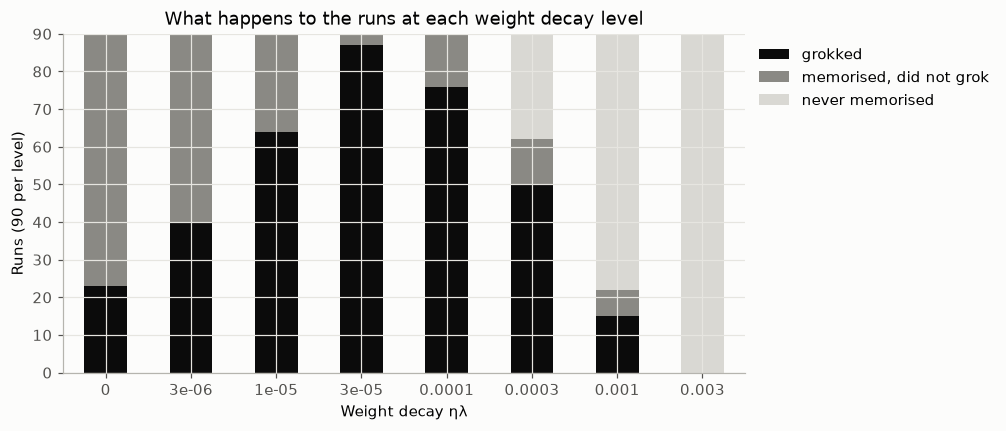

outcome,grokked,"memorised, did not grok",never memorised
0,23,67,0
3e-06,40,50,0
1e-05,64,26,0
3e-05,87,3,0
0.0001,76,14,0
0.0003,50,12,28
0.001,15,7,68
0.003,0,0,90


In [3]:
events['outcome'] = np.select([events['grokked'] == 1, events['t_mem99'].notna()],
                              ['grokked', 'memorised, did not grok'], default='never memorised')
outcome = pd.crosstab(events['eta_kappa'], events['outcome'])[['grokked', 'memorised, did not grok', 'never memorised']]
outcome.index = [f'{w:g}' for w in outcome.index]

ax = outcome.plot.bar(stacked=True, color=[INK, GREY, '#d9d8d3'], rot=0, figsize=(8, 4))
ax.set_xlabel('Weight decay ηλ')
ax.set_ylabel('Runs (90 per level)')
ax.set_title('What happens to the runs at each weight decay level')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()
outcome

**Takeaway.** Weight decay sets the outcome. Without it most runs memorise but never grok. At 3e-5 nearly all of them grok. From 3e-4 up many runs never memorise, and at 3e-3 none do, so we drop that level from here on.

## Part 2. How long does grokking take at each level?

A **Kaplan-Meier curve** shows the share of runs that haven't grokked yet at each step. A censored run counts as "not yet" for the whole budget, so nothing is thrown away (report Eq. 9). The report draws one curve per cell. Here we pool the cells of each level to see the big picture. The level 3e-3 is left out because none of its runs memorise.

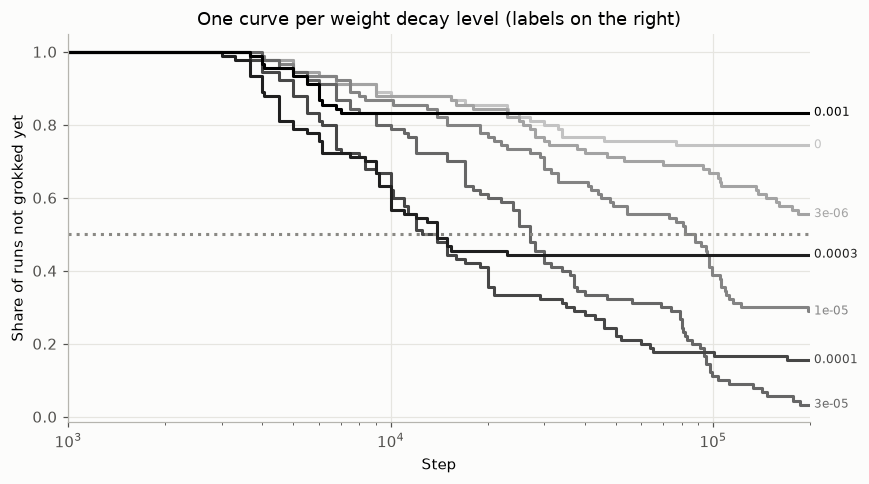

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
shades = plt.cm.Greys(np.linspace(0.35, 1, pooled['eta_kappa'].nunique()))
for shade, (level, g) in zip(shades, pooled.groupby('eta_kappa')):
    km = KaplanMeierFitter().fit(g['T'], g['grokked'])
    km.survival_function_.plot(ax=ax, drawstyle='steps-post', color=shade, legend=False)
    ax.text(200_000, km.survival_function_.iloc[-1, 0], f' {level:g}', va='center', fontsize=8, color=shade)
ax.set_xscale('log')
ax.set_xlim(1_000, 200_000)
ax.axhline(0.5, color=GREY, linestyle=':')
ax.set_xlabel('Step')
ax.set_ylabel('Share of runs not grokked yet')
ax.set_title('One curve per weight decay level (labels on the right)')
plt.tight_layout()
plt.show()

Where a curve crosses the dotted line at one half, we can read off the median grokking step. The next picture gives that median for every mix of `alpha` and weight decay.

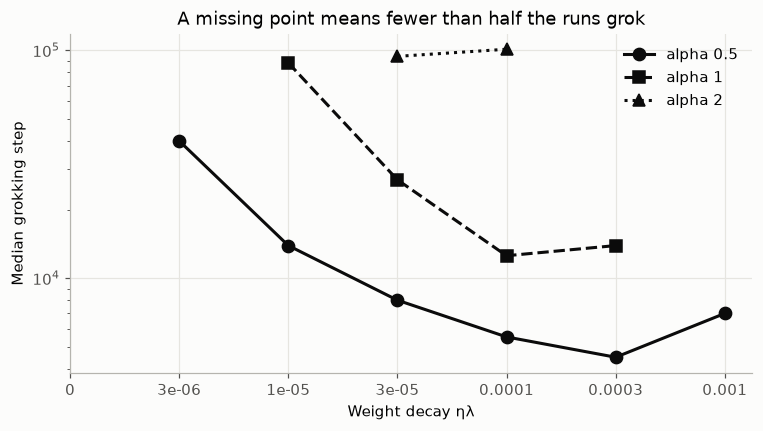

eta_kappa,0.000000,0.000003,0.000010,0.000030,0.000100,0.000300,0.001000
alpha,,,,,,,
0.5,NaN,40000.0,13894.0,8000.0,5520.0,4496.0,7000.0
1.0,NaN,NaN,88000.0,27000.0,12539.0,13894.0,NaN
2.0,NaN,NaN,NaN,94000.0,101000.0,NaN,NaN


In [5]:
rows = []
for (a, w), g in pooled.groupby(['alpha', 'eta_kappa']):
    km = KaplanMeierFitter().fit(g['T'], g['grokked'])
    rows.append({'alpha': a, 'eta_kappa': w, 'median T': km.median_survival_time_})
medians = pd.DataFrame(rows).replace(np.inf, np.nan)
levels = sorted(pooled['eta_kappa'].unique())

fig, ax = plt.subplots(figsize=(8, 4))
for a, (marker, line) in {0.5: ('o', '-'), 1.0: ('s', '--'), 2.0: ('^', ':')}.items():
    m = medians[medians['alpha'] == a]
    ax.plot([levels.index(w) for w in m['eta_kappa']], m['median T'], marker=marker, linestyle=line,
            color=INK, markersize=8, label=f'alpha {a:g}')
ax.set_xticks(range(len(levels)), [f'{w:g}' for w in levels])
ax.set_yscale('log')
ax.set_xlabel('Weight decay ηλ')
ax.set_ylabel('Median grokking step')
ax.set_title('A missing point means fewer than half the runs grok')
ax.legend()
plt.show()
medians.pivot(index='alpha', columns='eta_kappa', values='median T')

**Takeaway.**

- The curves cross. 3e-5 starts slower than 1e-4 but ends with the fewest runs left. So weight decay doesn't speed every run up by the same factor, and each level needs its own column in the models.
- A bigger `alpha` means a later grokking step at every weight decay level. At 3e-5 the median goes from 8,000 steps at `alpha` 0.5 to 94,000 at `alpha` 2.
- The band of weight decay in which runs grok gets narrower as `alpha` grows.

## Part 3. No peeking

A model may only use what is known before a run groks. We read the kernel at the landmark, step 2,430, and check that no run has grokked by then.

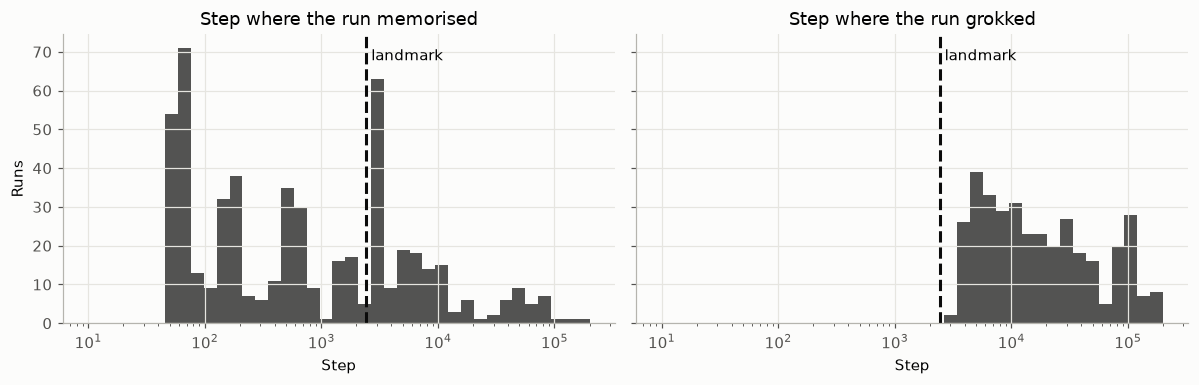

earliest grokking step (0.80)                 2983.000
highest test accuracy at the landmark            0.566
share of the spread in log T between cells       0.964
dtype: float64

In [6]:
earliest = events[['t_gen80', 't_gen90', 't_gen95']].min()
assert (earliest > LANDMARK).all(), 'a run grokked before the landmark'

bins = np.logspace(1, np.log10(200_000), 40)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, col, title in [(axes[0], 't_mem99', 'Step where the run memorised'),
                       (axes[1], 't_gen95', 'Step where the run grokked')]:
    ax.hist(pooled[col].dropna(), bins=bins, color=INK, alpha=0.7)
    ax.axvline(LANDMARK, color=INK, linestyle='--')
    ax.text(LANDMARK, 0.95, ' landmark', transform=ax.get_xaxis_transform(), va='top')
    ax.set_xscale('log')
    ax.set_xlabel('Step')
    ax.set_title(title)
axes[0].set_ylabel('Runs')
plt.tight_layout()
plt.show()

seen = pooled[pooled['grokked'] == 1]
log_T = np.log10(seen['T'])
pd.Series({'earliest grokking step (0.80)': earliest['t_gen80'],
           'highest test accuracy at the landmark': acc.loc[acc['step'] == LANDMARK, 'test_acc'].max(),
           'share of the spread in log T between cells': log_T.groupby(seen['cell']).transform('mean').var() / log_T.var()}).round(3)

**Takeaway.** No run groks before step 2,983, and at the landmark no run has a test accuracy above 0.57. 96% of the spread in log `T` lies between cells, so every score below holds out whole cells.

## Part 4. The ladder of models

We try four models, from the simplest up. Each gets three sets of inputs.

- **settings**: `alpha`, width and weight decay, as yes/no columns. One column per value lets each value have its own effect.
- **kernel**: `A_t`, `S_t` and `R_t` at the landmark.
- **both**: settings and kernel together.

If the kernel tells us something the settings don't, **both** should beat **settings**. Every score is on **held-out cells**: we fit on 125 cells and predict the one left out, for each cell in turn.

| Step | Model | Predicts | Runs it uses | Score |
| --- | --- | --- | --- | --- |
| 1 | Linear regression | log `T` | grokked runs only | concordance |
| 2 | Logistic regression | groks within the budget, yes or no | all | AUC |
| 3 | AFT | log `T` | all, with censored runs as "over 200,000" | concordance |
| 4 | Cox | the chance of grokking at the next step | all | concordance |

**Concordance** takes every pair of runs where we know which grokked first, and counts how often the model orders them right. **AUC** is the chance that a run that grokked gets a higher score than one that didn't. For both, 0.5 is a coin toss and 1 is perfect.

The yes/no columns look like this. The smallest value of each setting has no column, because it is the baseline.

In [7]:
dummies = pd.get_dummies(pooled[['alpha', 'width', 'eta_kappa']].astype('category'), drop_first=True, dtype=float)
dummies.head()

,alpha_1.0,alpha_2.0,width_100,width_200,width_400,width_800,width_1600,eta_kappa_3e-06,eta_kappa_1e-05,eta_kappa_3e-05,eta_kappa_0.0001,eta_kappa_0.0003,eta_kappa_0.001
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


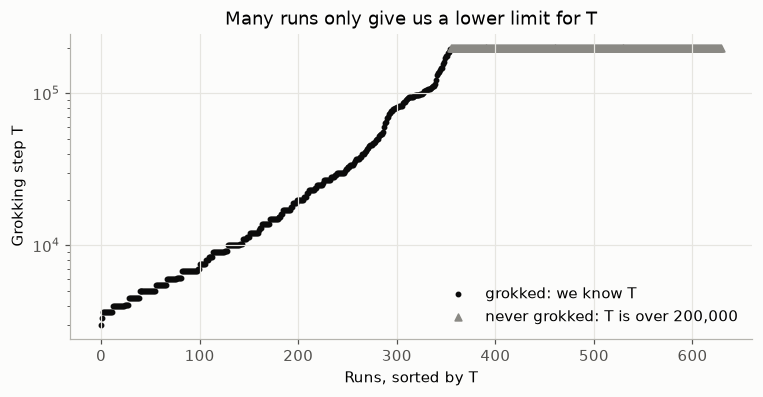

In [8]:
d = pooled.sort_values('T').reset_index(drop=True)
seen_T = d['grokked'] == 1
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.scatter(d.index[seen_T], d.loc[seen_T, 'T'], color=INK, s=8, label='grokked: we know T')
ax.scatter(d.index[~seen_T], d.loc[~seen_T, 'T'], color=GREY, marker='^', s=20, label='never grokked: T is over 200,000')
ax.set_yscale('log')
ax.set_xlabel('Runs, sorted by T')
ax.set_ylabel('Grokking step T')
ax.set_title('Many runs only give us a lower limit for T')
ax.legend(loc='lower right')
plt.show()

## Part 5. Step 1: linear regression

The simplest model is a straight line through log `T`. It needs a real `T`, so it **drops every run that never grokked**. `scores` collects every held-out score in this notebook.

In [9]:
scores = {}
g = pooled[pooled['grokked'] == 1].copy()
g_dummies = dummies.loc[g.index]
for cell in g['cell'].unique():
    train, test = g['cell'] != cell, g['cell'] == cell
    z = (g[kernel] - g.loc[train, kernel].mean()) / g.loc[train, kernel].std()
    for inputs, X in [('settings', g_dummies), ('kernel', z), ('both', g_dummies.join(z))]:
        line = LinearRegression().fit(X[train], np.log10(g.loc[train, 'T']))
        g.loc[test, f'lin_{inputs}'] = line.predict(X[test])
for inputs in INPUTS:
    scores[('linear regression', inputs)] = concordance_index(g['T'], g[f'lin_{inputs}'])
pd.Series({i: scores[('linear regression', i)] for i in INPUTS}, name='held-out concordance').round(3)

settings    0.857
kernel      0.733
both        0.870
Name: held-out concordance, dtype: float64

**Takeaway.** On the 355 grokked runs, the kernel adds a little: 0.857 with the settings and 0.870 with both. Keep in mind that this model has dropped the 275 runs that never grok.

## Part 6. Step 2: logistic regression

Next we keep every run but ask a simpler question: **will it grok within the budget, yes or no?** Logistic regression gives each run a probability of grokking.

In [10]:
for cell in pooled['cell'].unique():
    train, test = pooled['cell'] != cell, pooled['cell'] == cell
    z = (pooled[kernel] - pooled.loc[train, kernel].mean()) / pooled.loc[train, kernel].std()
    for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
        clf = LogisticRegression(max_iter=1000).fit(X[train], pooled.loc[train, 'grokked'])
        pooled.loc[test, f'prob_{inputs}'] = clf.predict_proba(X[test])[:, 1]

rows = {}
for inputs in INPUTS:
    scores[('logistic regression', inputs)] = roc_auc_score(pooled['grokked'], pooled[f'prob_{inputs}'])
    rows[inputs] = {'AUC': scores[('logistic regression', inputs)],
                    'balanced accuracy': balanced_accuracy_score(pooled['grokked'], pooled[f'prob_{inputs}'] > 0.5),
                    'accuracy': ((pooled[f'prob_{inputs}'] > 0.5) == pooled['grokked']).mean()}
pd.DataFrame(rows).T.round(3)

,AUC,balanced accuracy,accuracy
settings,0.955,0.877,0.878
kernel,0.732,0.583,0.598
both,0.951,0.860,0.860


**Balanced accuracy** averages the hit rate on grokked runs and on the others, so always guessing one answer scores 0.5. A **confusion matrix** counts right and wrong guesses with a cut at probability 0.5.

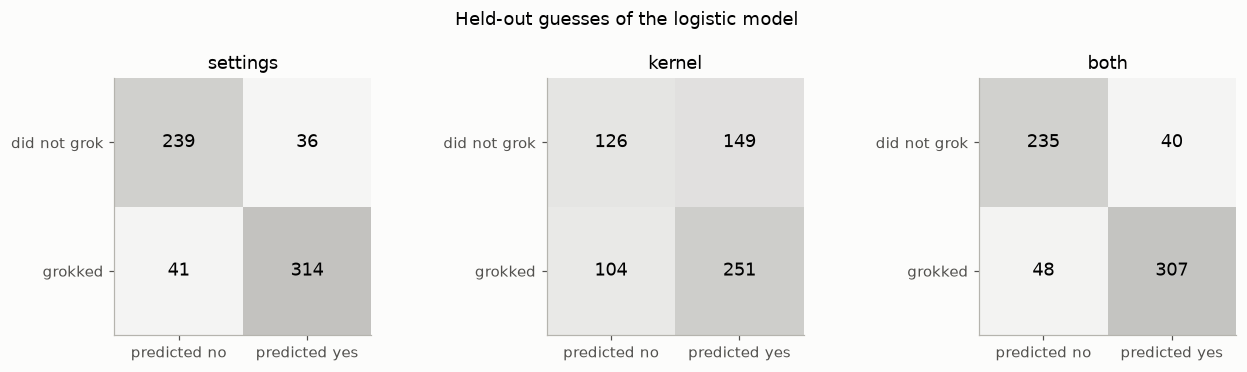

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, inputs in zip(axes, INPUTS):
    guess = (pooled[f'prob_{inputs}'] > 0.5).astype(int)
    matrix = pd.crosstab(pooled['grokked'], guess).reindex(index=[0, 1], columns=[0, 1], fill_value=0).to_numpy()
    ax.imshow(matrix, cmap=LinearSegmentedColormap.from_list('n', [SURFACE, GREY]), vmin=0, vmax=len(pooled))
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=12)
    ax.set_xticks([0, 1], ['predicted no', 'predicted yes'])
    ax.set_yticks([0, 1], ['did not grok', 'grokked'])
    ax.set_title(inputs)
    ax.grid(False)
fig.suptitle('Held-out guesses of the logistic model')
plt.tight_layout()
plt.show()

Where do the mistakes fall? Here is the share of runs guessed right, by setting, for **settings** against **both**.

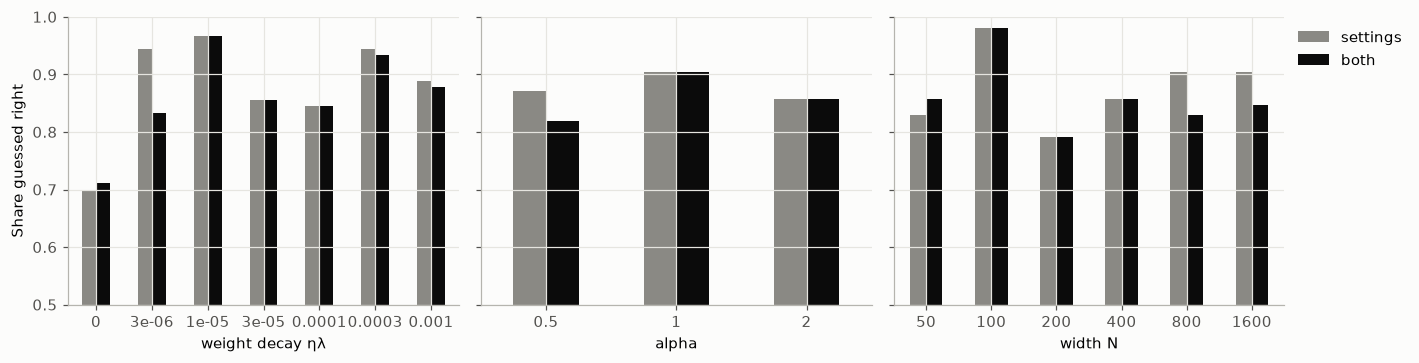

In [12]:
for inputs in ['settings', 'both']:
    pooled[f'right_{inputs}'] = (pooled[f'prob_{inputs}'] > 0.5) == pooled['grokked']

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, col in zip(axes, ['eta_kappa', 'alpha', 'width']):
    right = pooled.groupby(col)[['right_settings', 'right_both']].mean()
    right.index = [f'{v:g}' for v in right.index]
    right.plot.bar(ax=ax, color=[GREY, INK], rot=0, ylim=(0.5, 1), legend=False)
    ax.set_xlabel({'eta_kappa': 'weight decay ηλ', 'alpha': 'alpha', 'width': 'width N'}[col])
axes[0].set_ylabel('Share guessed right')
axes[2].legend(['settings', 'both'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Takeaway.**

- The settings alone get 0.878 of the runs right (AUC 0.955). Adding the kernel doesn't help (AUC 0.951).
- The kernel alone does much worse (AUC 0.732).
- The kernel helps at some levels and hurts at others. Without weight decay it lifts the share right from 0.70 to 0.71. At 3e-6 it drops it from 0.94 to 0.83.

## Part 7. Step 3: the AFT model

Linear regression drops the runs that never grok. Logistic regression keeps them but forgets the timing. The **accelerated failure time (AFT)** model does both jobs (report Eq. 10 and 11).

It's a linear regression on log `T` with one upgrade. When a run grokked, we know `T`, and the model fits it like normal regression. When it didn't, we only know `T` is over 200,000, and the model uses exactly that: it asks for a line that makes "over 200,000" likely for that run. Each input stretches or squeezes the time. A coefficient `a` multiplies the median grokking step by e^a, so a negative `a` means sooner.

A tiny penalty (0.01) keeps the fit stable when a setting has few grokked runs. The loop takes about a minute.

In [13]:
for cell in pooled['cell'].unique():
    train, test = pooled['cell'] != cell, pooled['cell'] == cell
    z = (pooled[kernel] - pooled.loc[train, kernel].mean()) / pooled.loc[train, kernel].std()
    for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
        aft = LogNormalAFTFitter(penalizer=0.01).fit(X[train].assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
        pooled.loc[test, f'aft_{inputs}'] = aft.predict_median(X[test]).to_numpy().ravel()
for inputs in INPUTS:
    scores[('AFT', inputs)] = concordance_index(pooled['T'], pooled[f'aft_{inputs}'], pooled['grokked'])
pd.Series({i: scores[('AFT', i)] for i in INPUTS}, name='held-out concordance').round(3)

settings    0.876
kernel      0.689
both        0.874
Name: held-out concordance, dtype: float64

**Takeaway.** The AFT tells the same story. It scores 0.876 with the settings, 0.689 with the kernel alone and 0.874 with both.

### Which kernel numbers matter in the AFT?

We fit the **both** model on every run and read its three kernel coefficients. The **likelihood ratio test** asks whether the three together improve on the settings alone.

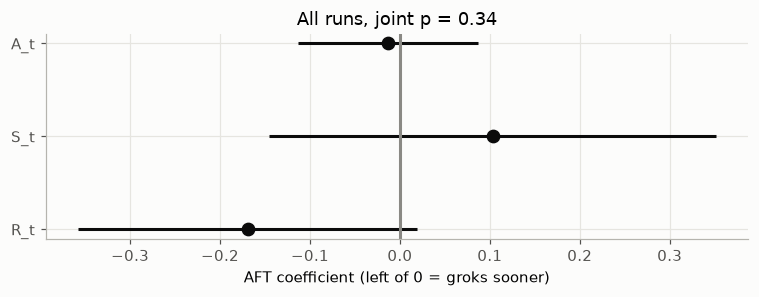

,coef,coef lower 95%,coef upper 95%,p,times the median
covariate,,,,,
A_t,-0.013,-0.113,0.087,0.798,0.987
S_t,0.103,-0.146,0.352,0.417,1.108
R_t,-0.169,-0.358,0.020,0.079,0.844


In [14]:
z = (pooled[kernel] - pooled[kernel].mean()) / pooled[kernel].std()
with_kernel = LogNormalAFTFitter(penalizer=0.01).fit(dummies.join(z).assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
without = LogNormalAFTFitter(penalizer=0.01).fit(dummies.assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
lr_p = chi2.sf(2 * (with_kernel.log_likelihood_ - without.log_likelihood_), 3)
coefs = with_kernel.summary.loc['mu_'].loc[kernel, ['coef', 'coef lower 95%', 'coef upper 95%', 'p']]
coefs['times the median'] = np.exp(coefs['coef'])

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.errorbar(coefs['coef'], range(3), xerr=[coefs['coef'] - coefs['coef lower 95%'], coefs['coef upper 95%'] - coefs['coef']],
            fmt='o', markersize=8, color=INK)
ax.axvline(0, color=GREY)
ax.set_yticks(range(3), kernel)
ax.invert_yaxis()
ax.set_xlabel('AFT coefficient (left of 0 = groks sooner)')
ax.set_title(f'All runs, joint p = {lr_p:.2g}')
plt.tight_layout()
plt.show()
coefs.round(3)

**Takeaway.**

- The three numbers together don't improve the fit on all runs (p = 0.34). `R_t` has the clearest coefficient, but it is not significant (p = 0.08). One standard deviation more rotation goes with a grokking step about 16 percent shorter (0.84 times the median).
- This agrees with the held-out scores, where the kernel adds nothing.
- These intervals count each seed as an independent run, so they are a bit too narrow.

## Part 8. Step 4: the Cox model

The Cox model doesn't predict a time. At every step it looks at the runs that haven't grokked yet and asks which one is most likely to grok next. That chance is the **hazard**. Each input multiplies the hazard by e^γ. So a **positive** γ means sooner, which is the opposite sign to the AFT (report Eq. 13 and 14).

We use it three ways.

- **(a)** With the kernel at the landmark, scored on held-out cells like the other models.
- **(b)** The report's own version, where the kernel changes along the run.
- **(c)** An extra that isn't in the report. It compares only the seeds of one cell, so the settings drop out.

### (a) The kernel at the landmark

In [15]:
for cell in pooled['cell'].unique():
    train, test = pooled['cell'] != cell, pooled['cell'] == cell
    z = (pooled[kernel] - pooled.loc[train, kernel].mean()) / pooled.loc[train, kernel].std()
    for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
        cox = CoxPHFitter(penalizer=0.01).fit(X[train].assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
        pooled.loc[test, f'cox_{inputs}'] = cox.predict_partial_hazard(X[test]).to_numpy().ravel()
for inputs in INPUTS:
    # a higher hazard means sooner, so we flip its sign before scoring
    scores[('Cox', inputs)] = concordance_index(pooled['T'], -pooled[f'cox_{inputs}'], pooled['grokked'])
pd.Series({i: scores[('Cox', i)] for i in INPUTS}, name='held-out concordance').round(3)

settings    0.879
kernel      0.697
both        0.880
Name: held-out concordance, dtype: float64

**Takeaway.** Same again: 0.879 with the settings and 0.880 with both.

### (b) The report's model: the kernel at every step

Here the kernel can change along the run (report Eq. 13). We cut each run into stretches between the saved steps. Each stretch carries the kernel from its start, so the model never sees the future. The report calls this left-continuous. A stretch gets `event` = 1 if the run groks inside it. We start at the landmark and fit each grokking level of the report: 0.80, 0.90 and 0.95.

In [16]:
long = kern.merge(pooled[['run_id', 'last_step', 't_gen80', 't_gen90', 't_gen95']], on='run_id').sort_values(['run_id', 'step'])
long['start'] = long['step']
long['next'] = long.groupby('run_id')['step'].shift(-1)     # the next saved step of the same run
long = long.dropna(subset=['next'])

tv_rows, tv_fits = {}, {}
for level in ['t_gen80', 't_gen90', 't_gen95']:
    lf = long.copy()
    lf['grokked'] = lf[level].notna().astype(int)
    lf['T'] = lf[level].fillna(lf['last_step'])
    lf = lf[(lf['start'] >= LANDMARK) & (lf['start'] < lf['T'])]      # from the landmark until the run groks
    lf['stop'] = np.minimum(lf['next'], lf['T'])
    lf['event'] = ((lf['stop'] == lf['T']) & (lf['grokked'] == 1)).astype(int)
    assert lf['event'].sum() == lf.groupby('run_id')['grokked'].first().sum()   # one event per grokked run
    at_lm = lf[lf['start'] == LANDMARK]
    lf[kernel] = (lf[kernel] - at_lm[kernel].mean()) / at_lm[kernel].std()
    ctv = CoxTimeVaryingFitter().fit(lf[['run_id', 'start', 'stop', 'event'] + kernel], id_col='run_id',
                                     event_col='event', start_col='start', stop_col='stop')
    tv_fits[level] = ctv.summary
    tv_rows[level] = {**ctv.summary['coef'].to_dict(), **ctv.summary['p'].add_prefix('p ').to_dict(),
                      'joint p': ctv.log_likelihood_ratio_test().p_value}

lf[['run_id', 'start', 'stop', 'event'] + kernel].head()

,run_id,start,stop,event,A_t,S_t,R_t
6024,ntk_N100_a0.5_wd0.0001_s0,2430,3305.0,0,-0.119515,2.160791,1.705137
6025,ntk_N100_a0.5_wd0.0001_s0,3305,3662.0,1,0.346839,2.934140,2.001511
6072,ntk_N100_a0.5_wd0.0001_s1,2430,3305.0,0,-1.724848,2.113138,1.181675
6073,ntk_N100_a0.5_wd0.0001_s1,3305,4000.0,1,-1.719515,3.026630,1.490349
6120,ntk_N100_a0.5_wd0.0001_s2,2430,3305.0,0,-0.603866,1.790989,1.699367


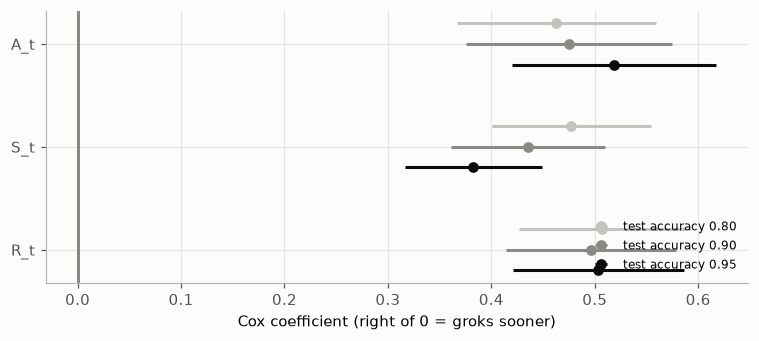

,A_t,S_t,R_t,p A_t,p S_t,p R_t,joint p
t_gen80,0.463,0.477,0.507,0.0,0.0,0.0,0.0
t_gen90,0.475,0.435,0.496,0.0,0.0,0.0,0.0
t_gen95,0.519,0.382,0.503,0.0,0.0,0.0,0.0


In [17]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for k, (level, shade) in enumerate([('t_gen80', '#c4c3bd'), ('t_gen90', GREY), ('t_gen95', INK)]):
    s = tv_fits[level]
    ax.errorbar(s['coef'], np.arange(3) + 0.2 * (k - 1), xerr=[s['coef'] - s['coef lower 95%'], s['coef upper 95%'] - s['coef']],
                fmt='o', color=shade, label=f'test accuracy 0.{level[-2:]}')
ax.axvline(0, color=GREY)
ax.set_yticks(range(3), kernel)
ax.invert_yaxis()
ax.set_xlabel('Cox coefficient (right of 0 = groks sooner)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()
pd.DataFrame(tv_rows).T.round(3)

**Takeaway.**

- At all three levels, all three numbers have positive coefficients with p below 0.001. As a run approaches grokking, a kernel that is bigger, more turned and better aligned goes with grokking soon.
- As in notebook 1, this model reads the kernel up to the step before grokking. It describes the run while it groks and gives no early warning. The report notes (§3.5) that these inputs come from the run itself, so the model says nothing about cause.

### (c) Extra: inside one cell

This Cox model gets one **stratum** per cell. Each cell has its own baseline, and the model only compares seeds of the same cell. So the settings drop out completely.

In [18]:
z = (pooled[kernel] - pooled[kernel].mean()) / pooled[kernel].std()
cox = CoxPHFitter().fit(pooled[['T', 'grokked', 'cell']].join(z), 'T', 'grokked', strata='cell', robust=True)
print('joint p', round(cox.log_likelihood_ratio_test().p_value, 4))
cox.summary[['coef', 'coef lower 95%', 'coef upper 95%', 'p']].round(3)

joint p 0.9733


,coef,coef lower 95%,coef upper 95%,p
covariate,,,,
A_t,0.002,-0.126,0.131,0.970
S_t,0.262,-0.565,1.090,0.535
R_t,-0.092,-0.548,0.364,0.692


The same idea as a picture, for the runs that grokked. Each dot is one seed. Its position shows how far its `A_t` and its grokking step sit above or below the average of its cell-mates.

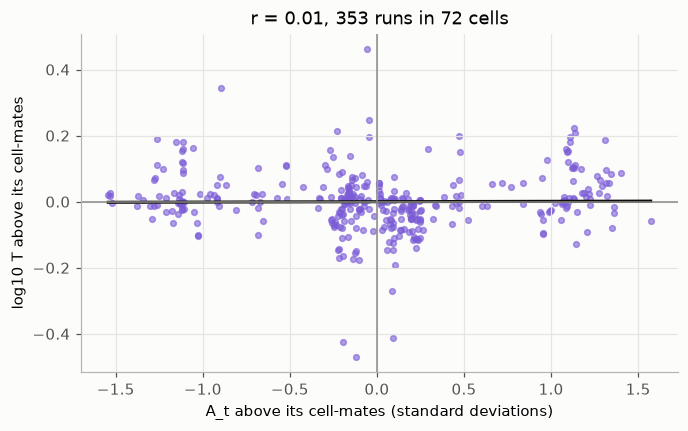

In [19]:
g = pooled[pooled['grokked'] == 1].copy()
g = g[g.groupby('cell')['T'].transform('size') >= 2]
z = (g['A_t'] - pooled['A_t'].mean()) / pooled['A_t'].std()
x = z - z.groupby(g['cell']).transform('mean')
y = np.log10(g['T']) - np.log10(g['T']).groupby(g['cell']).transform('mean')
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, color=KERNEL_COLOURS['A_t'], s=14, alpha=0.6)
ax.plot(np.sort(x), intercept + slope * np.sort(x), color=INK)
ax.axhline(0, color=GREY, linewidth=1)
ax.axvline(0, color=GREY, linewidth=1)
ax.set_xlabel('A_t above its cell-mates (standard deviations)')
ax.set_ylabel('log10 T above its cell-mates')
ax.set_title(f'r = {np.corrcoef(x, y)[0, 1]:.2f}, {len(g)} runs in {g["cell"].nunique()} cells')
plt.show()

**Takeaway.**

- Inside a cell, no number has a clear effect. The joint test of all three gives p = 0.97. `S_t` has a coefficient of 0.26 with p = 0.54.
- `A_t` shows nothing inside a cell (p = 0.97), and the picture has no slope (r = 0.01).

## Part 9. The four models side by side

Every held-out score from Parts 5 to 8 in one picture. Logistic regression is scored by AUC and the others by concordance. For both, 0.5 is a coin toss.

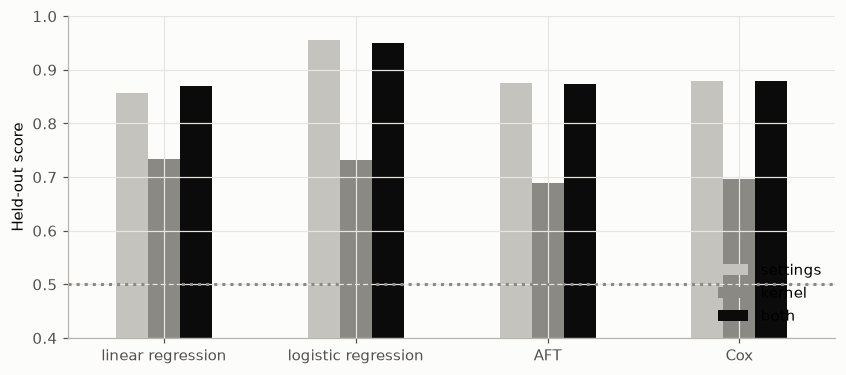

,settings,kernel,both
linear regression,0.857,0.733,0.870
logistic regression,0.955,0.732,0.951
AFT,0.876,0.689,0.874
Cox,0.879,0.697,0.880


In [20]:
models = ['linear regression', 'logistic regression', 'AFT', 'Cox']
table = pd.Series(scores).unstack().reindex(index=models, columns=INPUTS)
ax = table.plot.bar(rot=0, color=['#c4c3bd', GREY, INK], ylim=(0.4, 1), figsize=(9, 3.8), legend=False)
ax.axhline(0.5, color=GREY, linestyle=':')
ax.set_ylabel('Held-out score')
ax.legend(ax.containers, INPUTS, loc='lower right')
plt.show()
table.round(3)

### Which of `A_t`, `S_t` and `R_t` predicts?

Now each number goes in on its own, in every model. **Alone** shows everything the number knows, including what it knows about the settings. **On top of the settings** shows what it adds beyond them. This loop fits about 4,000 models and takes a few minutes.

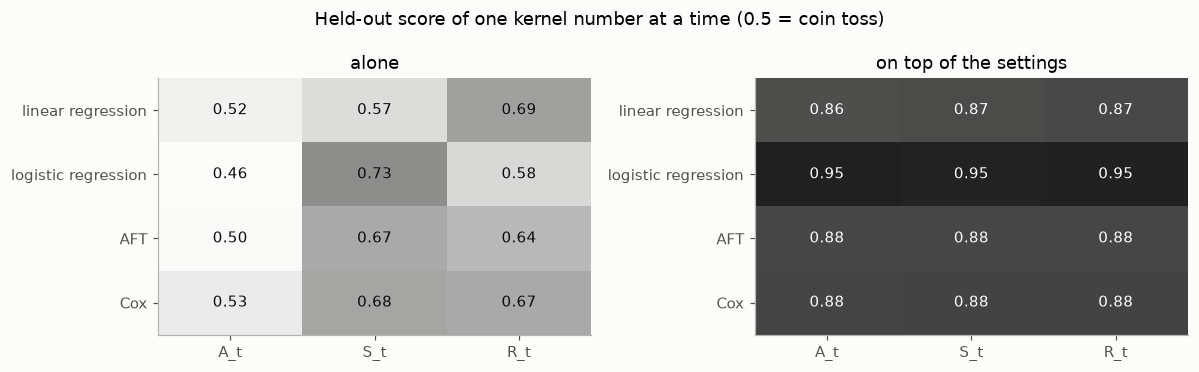

linear regression  logistic regression    AFT  \
alone                  A_t              0.523                0.464  0.505   
                       R_t              0.691                0.576  0.640   
                       S_t              0.566                0.729  0.671   
on top of the settings A_t              0.861                0.954  0.876   
                       R_t              0.872                0.953  0.875   
                       S_t              0.867                0.949  0.875   

                              Cox  
alone                  A_t  0.534  
                       R_t  0.670  
                       S_t  0.681  
on top of the settings A_t  0.879  
                       R_t  0.881  
                       S_t  0.881

In [21]:
one = {}
grok = pooled['grokked'] == 1
for number in kernel:
    for how in ['alone', 'on top of the settings']:
        pred = pd.DataFrame(index=pooled.index, columns=models, dtype=float)
        for cell in pooled['cell'].unique():
            train, test = pooled['cell'] != cell, pooled['cell'] == cell
            z = (pooled[[number]] - pooled.loc[train, [number]].mean()) / pooled.loc[train, [number]].std()
            X = z if how == 'alone' else dummies.join(z)
            fit_on = X[train].assign(T=pooled['T'], grokked=pooled['grokked'])
            if (test & grok).any():
                line = LinearRegression().fit(X[train & grok], np.log10(pooled.loc[train & grok, 'T']))
                pred.loc[test & grok, 'linear regression'] = line.predict(X[test & grok])
            clf = LogisticRegression(max_iter=1000).fit(X[train], pooled.loc[train, 'grokked'])
            pred.loc[test, 'logistic regression'] = clf.predict_proba(X[test])[:, 1]
            aft = LogNormalAFTFitter(penalizer=0.01).fit(fit_on, 'T', 'grokked')
            pred.loc[test, 'AFT'] = aft.predict_median(X[test]).to_numpy().ravel()
            cox = CoxPHFitter(penalizer=0.01).fit(fit_on, 'T', 'grokked')
            pred.loc[test, 'Cox'] = -cox.predict_partial_hazard(X[test]).to_numpy().ravel()
        one[(how, number)] = {
            'linear regression': concordance_index(pooled.loc[grok, 'T'], pred.loc[grok, 'linear regression']),
            'logistic regression': roc_auc_score(pooled['grokked'], pred['logistic regression']),
            'AFT': concordance_index(pooled['T'], pred['AFT'], pooled['grokked']),
            'Cox': concordance_index(pooled['T'], pred['Cox'], pooled['grokked'])}
one = pd.DataFrame(one).T.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, how in zip(axes, ['alone', 'on top of the settings']):
    m = one.loc[how].T.reindex(index=models, columns=kernel)
    ax.imshow(m, cmap=LinearSegmentedColormap.from_list('s', [SURFACE, INK]), vmin=0.5, vmax=1, aspect='auto')
    for r in range(m.shape[0]):
        for c in range(m.shape[1]):
            v = m.iloc[r, c]
            ax.text(c, r, f'{v:.2f}', ha='center', va='center', color='white' if v > 0.8 else INK)
    ax.set_xticks(range(3), kernel)
    ax.set_yticks(range(len(models)), models)
    ax.set_title(how)
    ax.grid(False)
fig.suptitle('Held-out score of one kernel number at a time (0.5 = coin toss)')
plt.tight_layout()
plt.show()
one.round(3)

**Takeaway.**

- **All four models agree.** Pooled, the kernel adds nothing on top of the settings. The largest gain is 0.01, for linear regression on the grokked runs only.
- **Alone,** `S_t` and `R_t` reach 0.57 to 0.73, and `A_t` stays near a coin toss (0.46 to 0.53). A score below 0.5 is the hold-out loop's way of saying a number carries almost no signal.
- **On top of the settings,** each number scores within 0.02 of the settings alone.

## Part 10. What `alpha` does

`alpha` turned out to matter a lot in the settings. This part looks at it on its own.

### Where runs grok, by `alpha` and weight decay

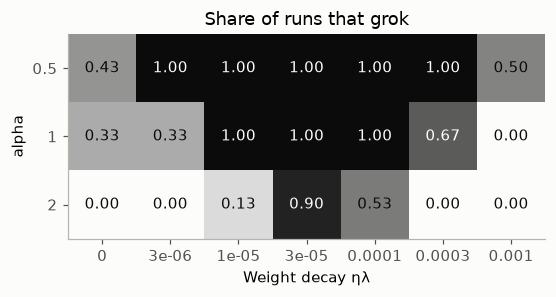

In [22]:
share = pooled.pivot_table(index='alpha', columns='eta_kappa', values='grokked', aggfunc='mean')
share.columns = [f'{w:g}' for w in share.columns]
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.imshow(share, cmap=LinearSegmentedColormap.from_list('share', [SURFACE, INK]), vmin=0, vmax=1)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        v = share.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white' if v > 0.6 else INK)
ax.set_xticks(range(share.shape[1]), share.columns)
ax.set_yticks(range(3), ['0.5', '1', '2'])
ax.set_xlabel('Weight decay ηλ')
ax.set_ylabel('alpha')
ax.set_title('Share of runs that grok')
ax.grid(False)
plt.tight_layout()
plt.show()

### How much `alpha` and width stretch the grokking step

We fit the settings-only AFT on every run. Then e^a turns each coefficient into "times the median grokking step", compared with `alpha` 0.5 or width 50 at the same other settings.

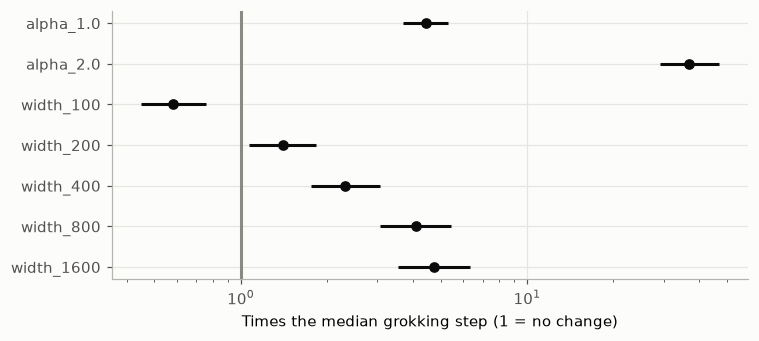

,times the median,lower 95%,upper 95%
covariate,,,
alpha_1.0,4.43,3.69,5.32
alpha_2.0,36.90,29.06,46.85
width_100,0.58,0.45,0.76
width_200,1.40,1.07,1.84
width_400,2.32,1.76,3.06
width_800,4.08,3.06,5.44
width_1600,4.74,3.55,6.33


In [23]:
settings_fit = LogNormalAFTFitter(penalizer=0.01).fit(dummies.assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
alpha_width = [c for c in dummies if c.startswith(('alpha', 'width'))]
multipliers = np.exp(settings_fit.summary.loc['mu_'].loc[alpha_width, ['coef', 'coef lower 95%', 'coef upper 95%']])
multipliers.columns = ['times the median', 'lower 95%', 'upper 95%']

fig, ax = plt.subplots(figsize=(7, 3.2))
m = multipliers
ax.errorbar(m['times the median'], range(len(m)), xerr=[m['times the median'] - m['lower 95%'], m['upper 95%'] - m['times the median']],
            fmt='o', color=INK)
ax.axvline(1, color=GREY)
ax.set_xscale('log')
ax.set_yticks(range(len(m)), m.index)
ax.invert_yaxis()
ax.set_xlabel('Times the median grokking step (1 = no change)')
plt.tight_layout()
plt.show()
multipliers.round(2)

**Takeaway.** Compared with `alpha` 0.5, `alpha` 1 multiplies the median grokking step by 4.4 and `alpha` 2 by 37. Width matters less. Width 100 is the fastest (0.58 times width 50) and width 1600 the slowest (4.7 times). The intervals count seeds as independent, so they are too narrow.

### The kernel at the landmark for each `alpha`

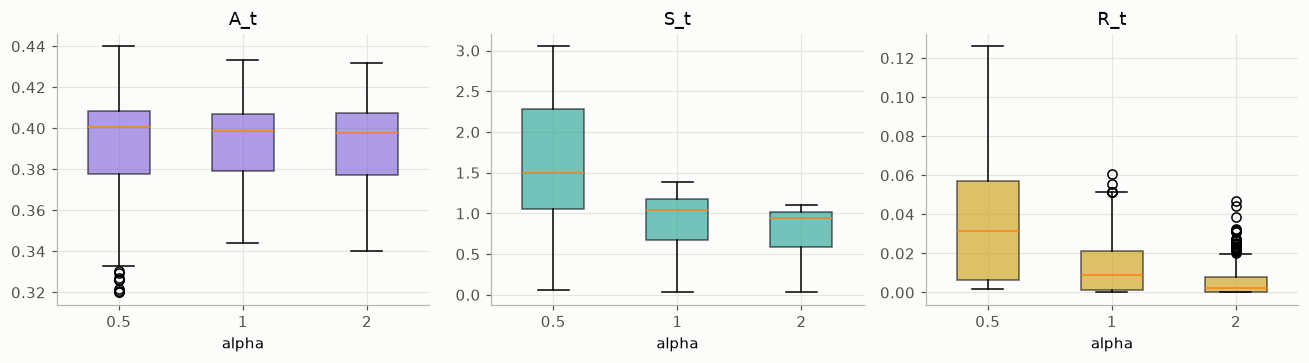

,A_t,S_t,R_t
alpha,,,
0.5,0.401,1.498,0.031
1.0,0.399,1.037,0.009
2.0,0.398,0.942,0.002


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, number in zip(axes, kernel):
    groups = [g[number] for _, g in pooled.groupby('alpha')]
    box = ax.boxplot(groups, tick_labels=['0.5', '1', '2'], patch_artist=True, widths=0.5)
    for patch in box['boxes']:
        patch.set_facecolor(KERNEL_COLOURS[number])
        patch.set_alpha(0.6)
    ax.set_xlabel('alpha')
    ax.set_title(number)
plt.tight_layout()
plt.show()
pooled.groupby('alpha')[kernel].median().round(3)

**Takeaway.** A bigger `alpha` means a kernel that has grown and turned less by the landmark, which is what the laziness knob should do. `A_t` hardly differs between the values of `alpha`, with a median of 0.40 in all three.

### Does the kernel still help inside one value of `alpha`?

Each value of `alpha` has 42 cells. We repeat the held-out AFT and logistic tests inside each one, with width and weight decay as the settings.

In [25]:
rows = {}
for a in sorted(pooled['alpha'].unique()):
    df = pooled[pooled['alpha'] == a].copy()
    d_a = pd.get_dummies(df[['width', 'eta_kappa']].astype('category'), drop_first=True, dtype=float)
    for cell in df['cell'].unique():
        train, test = df['cell'] != cell, df['cell'] == cell
        z = (df[kernel] - df.loc[train, kernel].mean()) / df.loc[train, kernel].std()
        for inputs, X in [('settings', d_a), ('both', d_a.join(z))]:
            aft = LogNormalAFTFitter(penalizer=0.01).fit(X[train].assign(T=df['T'], grokked=df['grokked']), 'T', 'grokked')
            df.loc[test, f'a_{inputs}'] = aft.predict_median(X[test]).to_numpy().ravel()
            clf = LogisticRegression(max_iter=1000).fit(X[train], df.loc[train, 'grokked'])
            df.loc[test, f'p_{inputs}'] = clf.predict_proba(X[test])[:, 1]
    rows[f'alpha {a:g}'] = {'cells with a grokked run': df.loc[df['grokked'] == 1, 'cell'].nunique(),
                            'AFT concordance, settings': concordance_index(df['T'], df['a_settings'], df['grokked']),
                            'AFT concordance, both': concordance_index(df['T'], df['a_both'], df['grokked']),
                            'AUC, settings': roc_auc_score(df['grokked'], df['p_settings']),
                            'AUC, both': roc_auc_score(df['grokked'], df['p_both'])}
pd.DataFrame(rows).T.round(3)

,cells with a grokked run,"AFT concordance, settings","AFT concordance, both","AUC, settings","AUC, both"
alpha 0.5,36.0,0.824,0.844,0.938,0.903
alpha 1,26.0,0.824,0.826,0.935,0.941
alpha 2,12.0,0.852,0.867,0.915,0.922


**Takeaway.** Inside one value of `alpha` the kernel still adds little. The AFT concordance moves by 0.020 at most, and the AUC falls at `alpha` 0.5 (0.938 to 0.903).

### Is the kernel standing in for mixes of `alpha` and weight decay?

The settings model gives `alpha` and weight decay one effect each. It can't say "`alpha` 2 only groks in a narrow band of weight decay". Maybe the kernel helps because it carries that. So we give the settings one column per mix of `alpha` and weight decay, and check whether the kernel still adds anything.

In [26]:
pooled['alpha_wd'] = pooled['alpha'].astype(str) + '_' + pooled['eta_kappa'].map('{:g}'.format)
combos = pd.get_dummies(pooled[['alpha_wd', 'width']].astype('category'), drop_first=True, dtype=float)
for cell in pooled['cell'].unique():
    train, test = pooled['cell'] != cell, pooled['cell'] == cell
    z = (pooled[kernel] - pooled.loc[train, kernel].mean()) / pooled.loc[train, kernel].std()
    for inputs, X in [('combos', combos), ('combos_kernel', combos.join(z))]:
        aft = LogNormalAFTFitter(penalizer=0.01).fit(X[train].assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
        pooled.loc[test, f'aft_{inputs}'] = aft.predict_median(X[test]).to_numpy().ravel()
        clf = LogisticRegression(max_iter=1000).fit(X[train], pooled.loc[train, 'grokked'])
        pooled.loc[test, f'prob_{inputs}'] = clf.predict_proba(X[test])[:, 1]

rows = {}
for inputs, name in [('settings', 'settings'), ('both', 'settings + kernel'),
                     ('combos', 'mixes of alpha and weight decay'), ('combos_kernel', 'mixes + kernel')]:
    rows[name] = {'AFT concordance': concordance_index(pooled['T'], pooled[f'aft_{inputs}'], pooled['grokked']),
                  'logistic AUC': roc_auc_score(pooled['grokked'], pooled[f'prob_{inputs}'])}
pd.DataFrame(rows).T.round(3)

,AFT concordance,logistic AUC
settings,0.876,0.955
settings + kernel,0.874,0.951
mixes of alpha and weight decay,0.884,0.963
mixes + kernel,0.882,0.951


**Takeaway.** One column per mix of `alpha` and weight decay helps the settings a little (0.884). The kernel still adds nothing on top (0.882).

### Can a model predict a value of `alpha` it has never seen?

We hold out one value of `alpha`, train on the other two, and predict it. The models get no `alpha` column, so they have to work out its effect from what they see.

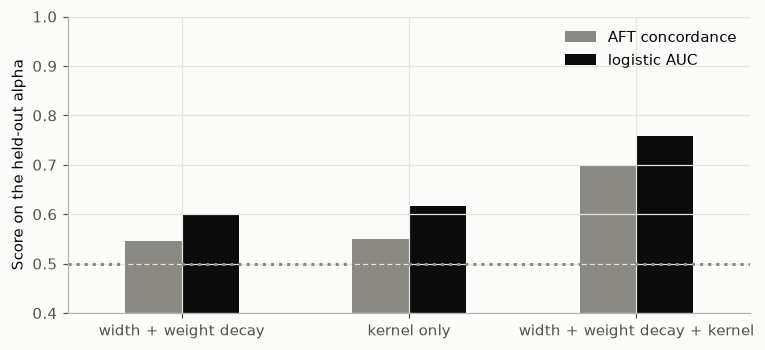

,AFT concordance,logistic AUC
width + weight decay,0.545,0.601
kernel only,0.550,0.617
width + weight decay + kernel,0.698,0.759


In [27]:
width_wd = pd.get_dummies(pooled[['width', 'eta_kappa']].astype('category'), drop_first=True, dtype=float)
rows = {}
for name, use_settings, use_kernel in [('width + weight decay', True, False), ('kernel only', False, True),
                                       ('width + weight decay + kernel', True, True)]:
    pred = pd.Series(index=pooled.index, dtype=float)
    prob = pd.Series(index=pooled.index, dtype=float)
    for a in pooled['alpha'].unique():
        train, test = pooled['alpha'] != a, pooled['alpha'] == a
        X = pd.DataFrame(index=pooled.index)
        if use_settings:
            X = X.join(width_wd)
        if use_kernel:
            X = X.join((pooled[kernel] - pooled.loc[train, kernel].mean()) / pooled.loc[train, kernel].std())
        aft = LogNormalAFTFitter(penalizer=0.01).fit(X[train].assign(T=pooled['T'], grokked=pooled['grokked']), 'T', 'grokked')
        pred[test] = aft.predict_median(X[test]).to_numpy().ravel()
        prob[test] = LogisticRegression(max_iter=1000).fit(X[train], pooled.loc[train, 'grokked']).predict_proba(X[test])[:, 1]
    rows[name] = {'AFT concordance': concordance_index(pooled['T'], pred, pooled['grokked']),
                  'logistic AUC': roc_auc_score(pooled['grokked'], prob)}
held_alpha = pd.DataFrame(rows).T

ax = held_alpha.plot.bar(rot=0, color=[GREY, INK], ylim=(0.4, 1), figsize=(8, 3.5))
ax.axhline(0.5, color=GREY, linestyle=':')
ax.set_ylabel('Score on the held-out alpha')
plt.show()
held_alpha.round(3)

**Takeaway.**

- Width and weight decay alone can't place a value of `alpha` they haven't seen (0.545, close to a coin toss). The kernel alone can't either (0.550).
- Together they do better (0.698 for the AFT, an AUC of 0.759 for the logistic model). So the kernel carries part of what `alpha` does, and it shows only once the other settings are in.

## Summary

| Part | What we found |
| --- | --- |
| 1 and 2 | Weight decay sets the outcome, and `alpha` sets most of the timing. `alpha` 2 groks about 37 times later than `alpha` 0.5. |
| 3 | No run groks before the landmark at step 2,430. 96% of the spread in log `T` lies between cells. |
| 5 to 8 | Pooled, the kernel adds nothing to the settings on held-out cells, in all four models. |
| 8 | The report's time-varying Cox model links all three numbers to grokking as it happens. Inside a cell, no number shows a link. |
| 9 | Alone, `S_t` and `R_t` carry some signal, and `A_t` carries almost none. |
| 10 | A bigger `alpha` gives a kernel that has moved less by the landmark. The kernel helps place a held-out `alpha` only together with the other settings. |

**Conclusion.** With the report's kernel, the early values of `A_t`, `S_t` and `R_t` don't predict the grokking step any better than the settings of the run do. Within one weight decay level (notebook 1) they add a little. Across levels, the settings already carry what the kernel knows. The report's own time-varying Cox model does find a strong link while the run groks, through all three numbers. That link describes grokking as it happens and can't warn of it early. So the report can say that the kernel tracks grokking. On these data it is no early predictor beyond the settings.